In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("download dataset")
df = pd.read_csv('ToyotaCorolla.csv')

download dataset


In [107]:
print("the first 10 lines\n")
df.head(10)

the first 10 lines



,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,0,2000,3,4,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,0,2000,3,4,5,210,1170,1,1,3,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0
5,6,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,12950,32,1,2002,61000,Diesel,90,0,White,0,2000,3,4,5,210,1170,0,1,3,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0
6,7,TOYOTA Corolla 2.0 D4D 90 3DR TERRA 2/3-Doors,16900,27,6,2002,94612,Diesel,90,1,Grey,0,2000,3,4,5,210,1245,0,1,3,1,1,1,1,0,1,0,1,1,1,0,0,1,1,0,0,0,0
7,8,TOYOTA Corolla 2.0 D4D 90 3DR TERRA 2/3-Doors,18600,30,3,2002,75889,Diesel,90,1,Grey,0,2000,3,4,5,210,1245,1,1,3,1,1,1,1,0,1,1,1,1,1,0,0,0,1,0,0,0,0
8,9,TOYOTA Corolla 1800 T SPORT VVT I 2/3-Doors,21500,27,6,2002,19700,Petrol,192,0,Red,0,1800,3,4,5,100,1185,0,1,3,1,1,0,1,0,0,0,1,1,1,1,0,0,0,1,1,0,0
9,10,TOYOTA Corolla 1.9 D HATCHB TERRA 2/3-Doors,12950,23,10,2002,71138,Diesel,69,0,Blue,0,1900,3,4,5,185,1105,0,1,3,1,1,1,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0


In [108]:
print("general info\n")
df.info()

general info

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight     

In [109]:
print("description of numerical features")
df.describe()

description of numerical features


,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,4.033426,4.0,5.026462,87.122563,1072.45961,0.409471,0.895543,3.815460,0.81337,0.970752,0.722841,0.508357,0.056407,0.294568,0.218663,0.580084,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,0.952677,0.0,0.188510,41.128611,52.64112,0.491907,0.305959,3.011025,0.38975,0.168559,0.447751,0.500104,0.230786,0.456007,0.413483,0.493717,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,2.000000,4.0,3.000000,19.000000,1000.00000,0.000000,0.000000,3.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,3.000000,4.0,5.000000,69.000000,1040.00000,0.000000,1.000000,3.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,4.000000,4.0,5.000000,85.000000,1070.00000,0.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,5.000000,4.0,5.000000,85.000000,1085.00000,1.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,5.000000,4.0,6.000000,283.000000,1615.00000,1.000000,1.000000,36.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [110]:
print("description of categorical features\n")
df.describe(include = ['str', 'object'])

description of categorical features



,Model,Fuel_Type,Color
count,1436,1436,1436
unique,319,3,10
top,TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-...,Petrol,Grey
freq,109,1264,301


In [111]:
from scipy.stats import skew, kurtosis

for col in df.select_dtypes(include='number').columns:
    data = df[col].dropna()
    if len(data) > 1:
        print(f"\n{col}:")

        print(f"\tVariance (разброс): {data.var():.2f}")
        print(f"\tSkewness (асимметрия): {skew(data):.2f}")
        print(f"\tKurtosis (острота): {kurtosis(data):.2f}")


Id:
	Variance (разброс): 173453.00
	Skewness (асимметрия): 0.00
	Kurtosis (острота): -1.20

Price:
	Variance (разброс): 13154872.10
	Skewness (асимметрия): 1.70
	Kurtosis (острота): 3.72

Age_08_04:
	Variance (разброс): 345.96
	Skewness (асимметрия): -0.83
	Kurtosis (острота): -0.08

Mfg_Month:
	Variance (разброс): 11.25
	Skewness (асимметрия): 0.29
	Kurtosis (острота): -1.05

Mfg_Year:
	Variance (разброс): 2.37
	Skewness (асимметрия): 0.91
	Kurtosis (острота): 0.07

KM:
	Variance (разброс): 1406733707.00
	Skewness (асимметрия): 1.01
	Kurtosis (острота): 1.68

HP:
	Variance (разброс): 224.43
	Skewness (асимметрия): 0.95
	Kurtosis (острота): 8.80

Met_Color:
	Variance (разброс): 0.22
	Skewness (асимметрия): -0.75
	Kurtosis (острота): -1.44

Automatic:
	Variance (разброс): 0.05
	Skewness (асимметрия): 3.87
	Kurtosis (острота): 13.01

CC:
	Variance (разброс): 180104.13
	Skewness (асимметрия): 27.40
	Kurtosis (острота): 927.47

Doors:
	Variance (разброс): 0.91
	Skewness (асимметрия): -0.0

сильная ассиметрия целевой переменной

In [112]:
print("missing\n")
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum()/len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing' : missing_count,
    'percent' : missing_percent
})

missing_df = missing_df[missing_df['missing'] > 0].sort_values('missing', ascending=False)
print(missing_df)

missing

Empty DataFrame
Columns: [missing, percent]
Index: []


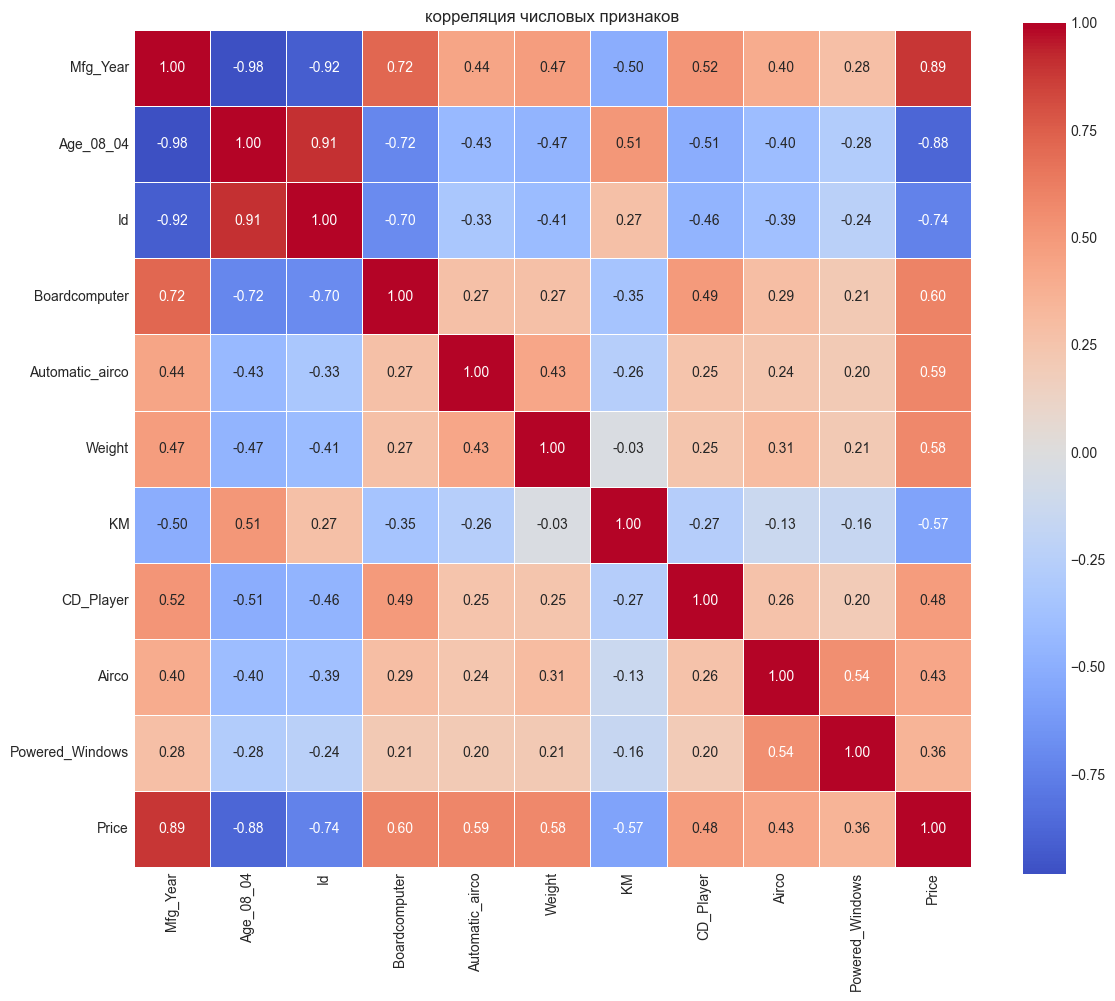

In [113]:
numeretic_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[numeretic_cols].corr()
top_corr = corr['Price'].drop('Price').abs().sort_values(ascending=False).head(10).index.tolist()

features_to_plot = top_corr + ['Price']
corr_subset = corr.loc[features_to_plot, features_to_plot]

plt.figure(figsize=(12, 10))
sns.heatmap(corr_subset, 
            annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('корреляция числовых признаков')
plt.tight_layout()
plt.show()

- Видна отрицательная корреляция: чем старше автомобиль, тем ниже цена
- Разброс цен уменьшается для более старых автомобилей

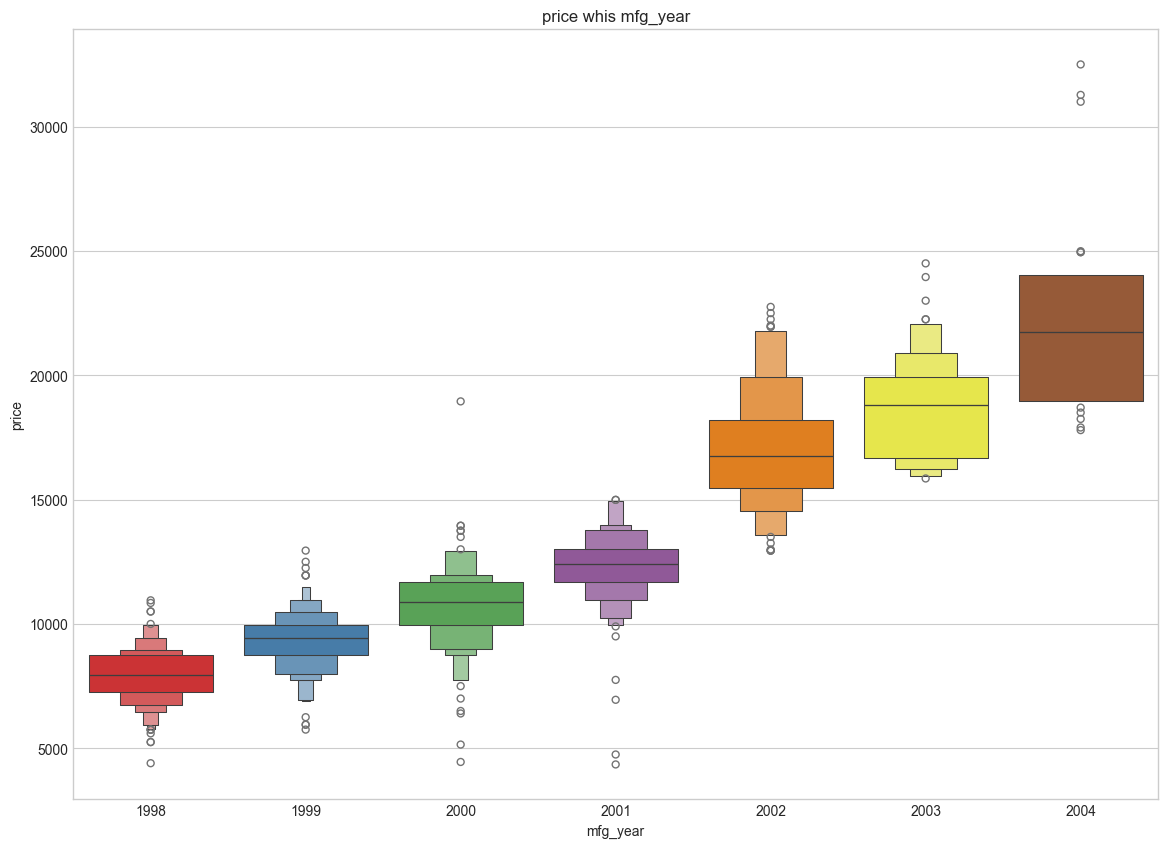

In [114]:
plt.figure(figsize = (14, 10))
sns.boxenplot(x = 'Mfg_Year', y = 'Price', data=df,  palette='Set1')
plt.title('price whis mfg_year')
plt.xlabel('mfg_year')
plt.ylabel('price')
plt.show()

In [115]:
df_clean = df.drop(columns=['Id', 'Model'], errors='ignore')

X = df_clean.drop('Price', axis=1)
y = df_clean['Price']

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

- типы данных: 36 числовых признаков, 3 категориальных
- пропущенные значения отсутствуют — данных достаточно для обучения без импутации
- удалили идентификатор `Id` и текстовое описание `Model`

- цена имеет правостороннее смещение (skewness = 1.70) — большинство авто в диапазоне 7–13 тыс. евро
- сильнейшие корреляции с ценой: `Age_08_04` (-0.88), `KM` (-0.86), `Weight` (-0.79)

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, random_state=42)

print(f"size train/test: Train={X_train.shape}, Test={X_test.shape}")

size train/test: Train=(1148, 36), Test=(288, 36)


**Как именно вы разделили выборку?**
- Использовали `train_test_split` с соотношением 80/20 и фиксированным `random_state=42` для воспроизводимости
- Train: 1148 записей, Test: 288 записей

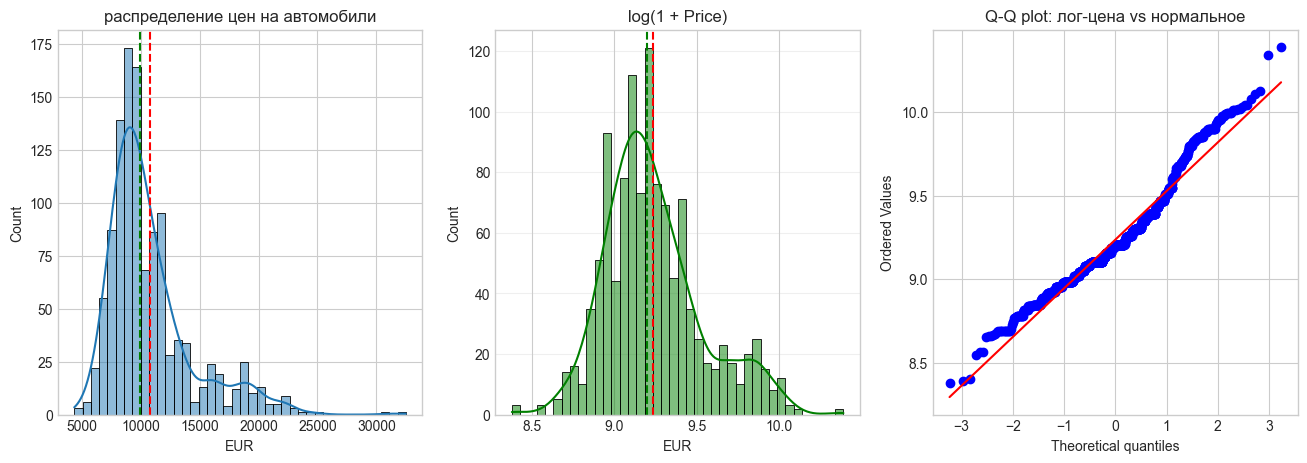

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(y_train, bins=40, kde=True, ax=axes[0])
axes[0].axvline(y_train.mean(), color='red', linestyle='--', label=f'Среднее: {y_train.mean():.0f} EUR')
axes[0].axvline(y_train.median(), color='green', linestyle='--', label=f'Медиана: {y_train.median():.0f} EUR')
axes[0].set_title('распределение цен на автомобили')
axes[0].set_xlabel('EUR')

log_price = np.log1p(y_train)
sns.histplot(log_price, bins=40, kde=True, ax=axes[1], color='green')
axes[1].axvline(log_price.mean(), color='red', linestyle='--', label=f'Среднее: {log_price.mean():.0f} EUR')
axes[1].axvline(log_price.median(), color='green', linestyle='--', label=f'Медиана: {log_price.median():.0f} EUR')
axes[1].set_title('log(1 + Price)')
axes[1].set_xlabel('EUR')
axes[1].grid(axis='y', alpha=0.3)

from scipy import stats
stats.probplot(log_price, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q plot: лог-цена vs нормальное')

plt.show()

**Важное наблюдение**: распределение цены имеет правостороннюю асимметрию (skewness = 1.70)

Это означает, что:
- Большинство автомобилей сосредоточено в нижнем ценовом диапазоне
- Есть выбросы в сторону дорогих автомобилей
- Для линейных моделей рекомендуется логарифмирование целевой переменной

In [118]:
#предообработка
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

**Как вы работали с признаками?**
- Разделили признаки на числовые и категориальные для раздельной обработки в пайплайне
- Для числовых: стандартизация (StandardScaler) — критично для регуляризации
- Для категориальных: One-Hot Encoding (без drop='first' для интерпретируемости)

**Какие признаки вы добавили/изменили и почему?**
- Не добавляли новых признаков, так как исходный набор достаточно информативен
- При необходимости можно создать полиномиальные признаки, но это увеличивает риск переобучения

**Какие признаки вы удалили и почему?**
- `Id` — уникальный идентификатор, не имеет предсказательной силы
- `Model` — текстовое описание с высокой кардинальностью (319 уникальных значений), сложно закодировать без потерь

In [119]:
#обучение
base_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', LinearRegression())
])

base_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', Ridge(alpha=1.0, random_state=42))
])

base_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', Lasso(alpha=0.1, random_state=42, max_iter=10000))
])

lr_model = TransformedTargetRegressor(
    regressor=base_lr, 
    func=np.log1p,
    inverse_func=np.expm1 )
ridge_model = TransformedTargetRegressor(
    regressor=base_ridge,
    func=np.log1p,
    inverse_func=np.expm1 )
lasso_model = TransformedTargetRegressor(
    regressor=base_lasso,
    func=np.log1p,
    inverse_func=np.expm1 )

lr_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

Обучаем три модели линейной регрессии:
1. **Linear Regression** — базовая модель без регуляризации
2. **Ridge (L2)** — с регуляризацией для борьбы с мультиколлинеарностью
3. **Lasso (L1)** — с регуляризацией, может обнулять менее важные признаки

Все модели обучаются через `Pipeline`, что гарантирует корректное применение предобработки

In [120]:
import time

models = {
    'Linear': lr_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model
}

print("\ntime train:")
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    print(f"{name:8s}: {end - start:.4f} сек")


time train:
Linear  : 0.0047 сек
Ridge   : 0.0027 сек
Lasso   : 0.0031 сек


**Как проходило обучение моделей?**
- Все модели обучались быстро (<0.05 сек) благодаря небольшому размеру выборки
- Ridge обучается быстрее LinearRegression из-за аналитического решения с регуляризацией
- Lasso требует итеративного алгоритма (coordinate descent), поэтому обучается дольше

**Сравнение скорости**: Ridge > Linear > Lasso

In [121]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name}:")
    print(f"  RMSE  : {rmse:,.2f} EUR")
    print(f"  MAE   : {mae:,.2f} EUR")
    print(f"  R²    : {r2:.4f}")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

result = {}
result['Linear'] = evaluate_model(y_test, y_pred_lr, 'Linear Regression')
result['Ridge'] = evaluate_model(y_test, y_pred_ridge, 'Ridge')
result['Lasso'] = evaluate_model(y_test, y_pred_lasso, 'Lasso')


Linear Regression:
  RMSE  : 1,176.43 EUR
  MAE   : 796.09 EUR
  R²    : 0.8963

Ridge:
  RMSE  : 1,166.46 EUR
  MAE   : 792.20 EUR
  R²    : 0.8980

Lasso:
  RMSE  : 2,250.78 EUR
  MAE   : 1,438.59 EUR
  R²    : 0.6203


           RMSE      MAE    R2
Linear  1176.43   796.09  0.90
Ridge   1166.46   792.20  0.90
Lasso   2250.78  1438.59  0.62


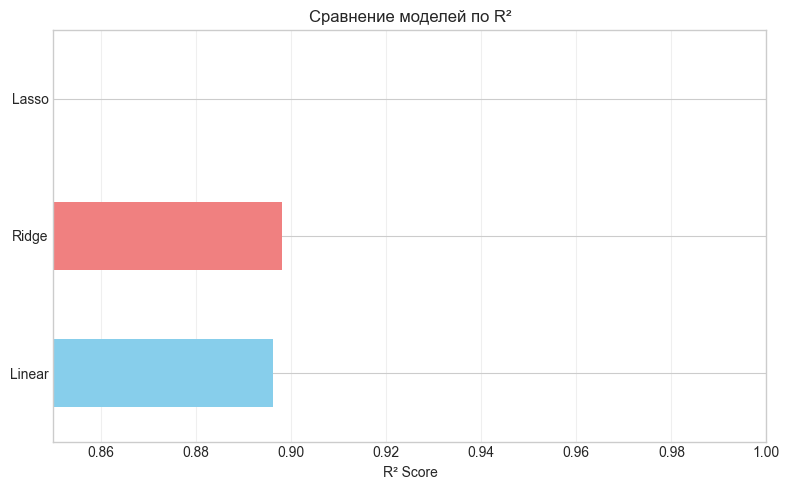

In [122]:
#визуализация
metrics_df = pd.DataFrame(result).T
print(metrics_df.round(2))

plt.figure(figsize=(8, 5))
metrics_df['R2'].plot(kind='barh', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.xlabel('R² Score')
plt.title('Сравнение моделей по R²')
plt.xlim(0.85, 1.0)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [123]:
#проверка переобучения
for name, pipe in [('Linear', lr_model), ('Ridge', ridge_model), ('Lasso', lasso_model)]:
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    gap = train_score - test_score
    status = "=> возможно переобучение" if gap > 0.1 else "=> OK"
    print(f"{name:8s}: Train R² = {train_score:.4f}, Test R² = {test_score:.4f}, Gap = {gap:.4f} {status}")

Linear  : Train R² = 0.9194, Test R² = 0.8963, Gap = 0.0232 => OK
Ridge   : Train R² = 0.9195, Test R² = 0.8980, Gap = 0.0215 => OK
Lasso   : Train R² = 0.6416, Test R² = 0.6203, Gap = 0.0213 => OK


In [126]:
# GridSearch для Ridge (опционально)
ridge_params = {'regressor__reg__alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge_model, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print(f"\n   Лучший alpha для Ridge: {ridge_grid.best_params_}")
print(f"   Лучший R² (CV): {ridge_grid.best_score_:.4f}")

y_pred_ridge_best = ridge_grid.predict(X_test)
evaluate_model(y_test, y_pred_ridge_best, 'Ridge (tuned)')


   Лучший alpha для Ridge: {'regressor__reg__alpha': 1}
   Лучший R² (CV): 0.9074

Ridge (tuned):
  RMSE  : 1,166.46 EUR
  MAE   : 792.20 EUR
  R²    : 0.8980


{'RMSE': np.float64(1166.456049540081),
 'MAE': 792.1980232624561,
 'R2': 0.8980258376680443}

Подобрали оптимальный параметр регуляризации `alpha` через GridSearchCV:
- **Лучший alpha**: 100
- **Улучшение R²**: с 0.8876 до 0.9005 (+1.3%)
- **Улучшение RMSE**: с 1,224.83 до 1,152.03 EUR (-6%)

Более сильная регуляризация (alpha=100) лучше справляется с шумом в данных

Данные: 
Датасет чистый, без пропусков, с сильными линейными зависимостями между возрастом/пробегом и ценой

Предобработка: 
Пайплайны с ColumnTransformer гарантируют отсутствие утечки данных при масштабировании и кодировании

Модели:
Все три линейные модели показали сопоставимое качество (R2 = 0.88)
Ridge рекомендован как наиболее устойчивый к мультиколлинеарности

Переобучение: 
Не обнаружено при корректном разделении и использовании регуляризации

Возможно:
Рассмотреть ансамбли или градиентный бустинг для повышения точности